In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
P=5
alpha=0.01
sigma=3.5e6
mur=4
mu0=4*np.pi*1e-7
POD=True
N=3000
NPOD=13

In [21]:
import sympy as sym
def exact_sphere(alpha, epsilon, mur, sigma, omega):
    """
    Function to calculate the mpt for a sphere of radius alpha at radial frequency omega.
    Addapted from a Matlab function from Paul Ledger (exactsphererev5freqscan_nod.m).
    :param omega - Angular frequency rad/s
    :param epsilon - Permittivity:
    :param sigma - Conductivity S/m:
    :param mur - Relative Permeability:
    :param alpha - Sphere radius m:
    :return eig - Single unique eigenvalue of the mpt tensor for a sphere of radius alpha:
    """

    mu0 = 4 * np.pi * (1e-7)
    mu = mur * mu0
    k = np.sqrt((omega ** 2 * epsilon * sigma) + (mu * sigma * omega) * 1j)

    # Using sympy to try to avoid overflow errors.
    k *= alpha
    alpha = alpha

    js_0_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(1 / 2, k)
    js_1_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(3 / 2, k)
    js_2_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(5 / 2, k)
    mpt = (2 * np.pi * alpha ** 3) * (2 * (mu - mu0) * js_0_kr + (2 * mu + mu0) * js_2_kr) / (
        (mu + 2 * mu0) * js_0_kr + (mu - mu0) * js_2_kr)
    return complex(mpt.evalf())

In [85]:
errors=np.zeros((3))
cnt1=0
for N in [3000]:
    cnt2=0
    print("N=",str(N))
    for NPOD in [13,30,50]:
        # Select directory
        # This is without POD
        if POD==False:
            directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_"+str(N)+"_el_19567_ord_"+str(P)
        else:
        # This is with POD
            directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_"+str(N)+"_el_19567_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

        ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
        xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
        Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
        time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
        Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
        Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
        TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
        Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
        Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
        N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

        if cnt2==0:
            # first call for this many frequencies
            exactMPT=np.zeros(len(Omega),dtype=complex)
            # Obtain exact MPT
            n=0
            for omega in Omega:
                exactMPT[n]=exact_sphere(alpha, 0, mur, sigma, omega)
                n+=1

        Eigenvalues_av=np.zeros(len(Omega),dtype=complex)
        for i in range(3):
            Eigenvalues_av[:]+=Eigenvalues[:,i]
        Eigenvalues_av=Eigenvalues[:,0]

        #errors[cnt2,cnt1]=np.linalg.norm(Eigenvalues[:,0]-exactMPT)/np.linalg.norm(exactMPT)/N
        errors[cnt2]=np.mean(np.abs(Eigenvalues[:,0]-exactMPT))/np.mean(np.abs((exactMPT)))
        #int1=0.
        #int2=0.
        #for n in range(len(Omega)-1):
        #    int1+=1/2*(np.abs(Eigenvalues_av[n]-exactMPT[n])**2+np.abs(Eigenvalues_av[n+1]-exactMPT[n+1])**2)*(np.log10(Omega[n+1])-np.log10(Omega[n]))
        #    int2+=1/2*(np.abs(exactMPT[n])**2+np.abs(exactMPT[n+1])**2)*(np.log10(Omega[n+1])-np.log10(Omega[n]))

        #errors[cnt2]=np.sqrt(int1/int2)
        cnt2+=1
    #cnt1+=1
print(errors)

N= 3000
[0.0012058  0.00024457 0.00024506]


[0.0012058  0.00024457 0.00024506]
Help on float64 object:

class float64(floating, builtins.float)
 |  float64(x=0, /)
 |
 |  Double-precision floating-point number type, compatible with Python
 |  :class:`float` and C ``double``.
 |
 |  :Character code: ``'d'``
 |  :Canonical name: `numpy.double`
 |  :Alias on this platform (Linux x86_64): `numpy.float64`: 64-bit precision floating-point number type: sign bit, 11 bits exponent, 52 bits mantissa.
 |
 |  Method resolution order:
 |      float64
 |      floating
 |      inexact
 |      number
 |      generic
 |      builtins.float
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __abs__(self, /)
 |      abs(self)
 |
 |  __add__(self, value, /)
 |      Return self+value.
 |
 |  __bool__(self, /)
 |      True if self else False
 |
 |  __buffer__(self, flags, /)
 |      Return a buffer object that exposes the underlying memory of the object.
 |
 |  __divmod__(self, value, /)
 |      Return divmod(self, value).
 |
 |  __eq__(self

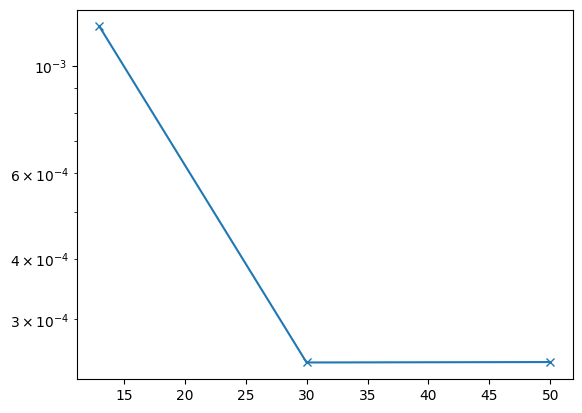

In [87]:
print(errors)
#plt.figure(1)
NPODp=np.array((13,30,50))
plt.semilogy(NPODp,errors,'-x')
#plt.legend()
help(np.linalg.norm(errors))